# Worksheet 4 -- Linear Regression

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('data.csv', on_bad_lines='skip', header=12)
sample_A = df.dropna()
sample_A['pl_masse_err'] = (np.abs(sample_A['pl_masseerr1']) + np.abs(sample_A['pl_masseerr2'])) / 2.0

print("The new dataset has {} planets. Down from the original {}.".format(len(sample_A), len(df)))

The new dataset has 2921 planets. Down from the original 39816.


In [3]:
sample_B = sample_A[sample_A['pl_rade'] <= 5]
print(sample_B)

          pl_name  pl_rade  pl_masse  pl_masseerr1  pl_masseerr2  st_mass  \
117      55 Cnc e    1.947      8.59          0.43         -0.43    1.015   
122      55 Cnc e    1.875      7.99          0.32         -0.33    0.905   
123      55 Cnc e    2.173      8.37          0.38         -0.38    0.900   
129      55 Cnc e    2.080      7.81          0.58         -0.53    0.905   
131      55 Cnc e    1.897      7.74          0.37         -0.30    0.873   
...           ...      ...       ...           ...           ...      ...   
39582  Wolf 503 b    2.043      6.26          0.69         -0.70    0.688   
39583  Wolf 503 b    2.043      6.27          0.85         -0.84    0.688   
39755    pi Men c    2.060      4.52          0.81         -0.81    1.020   
39759    pi Men c    2.110      4.30          0.70         -0.70    1.070   
39762    pi Men c    2.042      4.82          0.84         -0.86    1.094   

       pl_masse_err  
117           0.430  
122           0.325  
123      

Text(0, 0.5, 'Mass (Earth masses)')

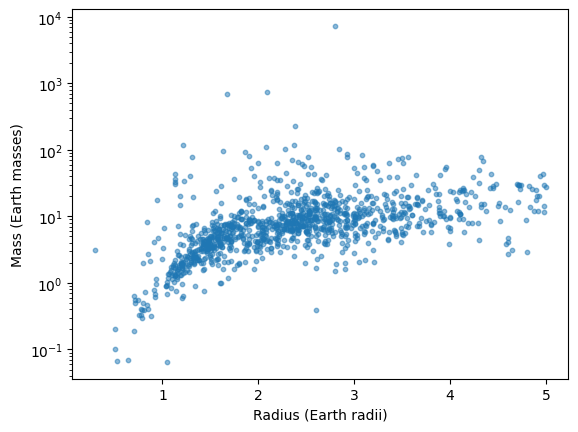

In [4]:
plt.scatter(sample_B['pl_rade'], sample_B['pl_masse'], alpha=0.5, s=10)
plt.yscale('log')
plt.xlabel('Radius (Earth radii)')
plt.ylabel('Mass (Earth masses)')

In [ ]:
EARTH_RADIUS_KM = 6378.13
EARTH_MASS = 5.972  # in units of 1e24 kg (= 1 Earth mass)

solar_system = {
    'Mercury': {'R_km': 2439.4, 'M_true': 0.330103},
    'Venus':   {'R_km': 6051.8, 'M_true': 4.86731},
    'Earth':   {'R_km': 6371.0084, 'M_true': 5.972},
    'Mars':    {'R_km': 3389.50, 'M_true': 0.641691},
    'Jupiter': {'R_km': 69911,  'M_true': 1898.125},
    'Saturn':  {'R_km': 58232,  'M_true': 568.317},
    'Uranus':  {'R_km': 25362,  'M_true': 86.8099},
    'Neptune': {'R_km': 24622,  'M_true': 102.4092},
}

def predict_solar_system(predict_fn):
    """Predict and compare mass for solar system planets."""
    for name, data in solar_system.items():
        R_earth = data['R_km'] / EARTH_RADIUS_KM
        log_R = np.log10(R_earth)
        log_M_pred = predict_fn(log_R)
        M_pred = 10**log_M_pred
        M_actual = data['M_true'] / EARTH_MASS
        print(f"{name:8s}: predicted = {M_pred:.3f}, actual = {M_actual:.3f}")

In [ ]:
# When all the uncertainties are the same, the least squares fit is equvalent to maximum likelihood estimate. We can use np.linalg.lstsq to find the best fit line.

# We are working in log space.
log_R = np.log10(sample_B['pl_rade'].values)
log_M = np.log10(sample_B['pl_masse'].values)

# lstsq expects a (M, N) array for the coefficient matrix.
X = np.column_stack([log_R, np.ones(len(log_R))])

coeffs_ols, residuals, rank, s = np.linalg.lstsq(X, log_M, rcond=None)
print(coeffs_ols, s)

In [ ]:
# Plot of best fit.
plt.plot(log_R, coeffs_ols[0] * log_R + coeffs_ols[1], label='Best-Fit', c='red')
plt.scatter(log_R, log_M, alpha=0.5, s=10, label="Data")
plt.xlabel('Radius (Earth radii)')
plt.ylabel('Mass (Earth masses)')
plt.legend(loc='upper left')

In [ ]:
predict_solar_system(lambda log_R: coeffs_ols[0] * log_R + coeffs_ols[1])

In [ ]:
# Propagate uncertainties into log space
# σ(log10 M) ≈ σ_M / (M * ln(10))
sigma_logM = sample_B['pl_masse_err'].values / (sample_B['pl_masse'].values * np.log(10))

# In WLS, we weight each data point by 1/σ², so we divide by the uncertainty
# This is equivalent to MLE with Gaussian errors
weights = 1.0 / sigma_logM

# Build the weighted design matrix and target
X = np.column_stack([log_R, np.ones(len(log_R))])
X_w = X * weights[:, np.newaxis]    # Multiply each row by its weight
y_w = log_M * weights               # Multiply target by same weights

# Solve the weighted normal equations
coeffs_wls, residuals_wls, rank_wls, s_wls = np.linalg.lstsq(X_w, y_w, rcond=None)

In [ ]:
plt.plot(log_R, coeffs_wls[0] * log_R + coeffs_wls[1], label='Best-Fit', c='red')
plt.scatter(log_R, log_M, alpha=0.5, s=10, label="Data")
plt.xlabel('Radius (Earth radii)')
plt.ylabel('Mass (Earth masses)')
plt.legend(loc='upper left')

In [ ]:
predict_solar_system(lambda log_R: coeffs_wls[0] * log_R + coeffs_wls[1])

In [ ]:
log_R_A = np.log10(sample_A['pl_rade'].values)
log_M_A = np.log10(sample_A['pl_masse'].values)
sigma_logM_A = sample_A['pl_masse_err'].values / (
    sample_A['pl_masse'].values * np.log(10))

# We need to create a smooth grid for plotting.
log_R_plot = np.linspace(log_R_A.min(), log_R_A.max(), len(log_R_A))

weights_A = 1.0 / sigma_logM_A

# Build a polynomial design matrix of degree d
# Each column is (log R)^k for k = 0, 1, ..., d
def make_poly_design_matrix(log_R, degree):
    return np.column_stack([log_R**k for k in range(degree + 1)])

d = 6
X_poly = make_poly_design_matrix(log_R_A, d)
X_poly_w = X_poly * weights_A[:, np.newaxis]
y_w_A = log_M_A * weights_A

coeffs_poly, residuals_poly, rank_poly, s_poly = np.linalg.lstsq(X_poly_w, y_w_A, rcond=None)
print(f"Polynomial coefficients (degree {d}): {coeffs_poly}")

In [ ]:
plt.plot(log_R_plot, np.polyval(coeffs_poly[::-1], log_R_plot), label='Best-Fit', c='red')
plt.scatter(log_R_A, log_M_A, alpha=0.5, s=10, label="Data")
plt.xlabel('Radius (Earth radii)')
plt.ylabel('Mass (Earth masses)')
plt.legend(loc='upper left')

In [ ]:
predict_solar_system(lambda log_R: np.polyval(coeffs_poly[::-1], log_R))

In [ ]:
log_R_B = np.log10(sample_B['pl_rade'].values)
log_Mstar_B = np.log10(sample_B['st_mass'].values)
log_M_B = np.log10(sample_B['pl_masse'].values)

sigma_logM_B = sample_B['pl_masse_err'].values / (
    sample_B['pl_masse'].values * np.log(10))
weights_B = 1.0 / sigma_logM_B

In [ ]:
X_2d = np.column_stack([log_R_B, log_Mstar_B, np.ones(len(log_R_B))])
X_2d_w = X_2d * weights_B[:, np.newaxis]
y_w_B = log_M_B * weights_B

In [ ]:
coeffs_2d, _, _, _ = np.linalg.lstsq(X_2d_w, y_w_B, rcond=None)
a, b, c = coeffs_2d
print(f"2D fit (sample B): log M = {a:.3f}·log R + {b:.3f}·log M★ + {c:.3f}")

In [ ]:
# Solar mass of the sun is 1.
log_Mstar_sun = np.log10(1.0)

print("Sample B (pl_rade <= 5):")
predict_solar_system(lambda log_R: a * log_R + b * log_Mstar_sun + c)

In [ ]:
# 2D fit on sample A (all planets)
log_Mstar_A = np.log10(sample_A['st_mass'].values)

X_2d_A = np.column_stack([log_R_A, log_Mstar_A, np.ones(len(log_R_A))])
X_2d_A_w = X_2d_A * weights_A[:, np.newaxis]

coeffs_2d_A, _, _, _ = np.linalg.lstsq(X_2d_A_w, y_w_A, rcond=None)
a_A, b_A, c_A = coeffs_2d_A
print(f"2D fit (sample A): log M = {a_A:.3f}·log R + {b_A:.3f}·log M★ + {c_A:.3f}")

In [ ]:
print("Sample A (all planets):")
predict_solar_system(lambda log_R: a_A * log_R + b_A * log_Mstar_sun + c_A)